# 05 — Optuna HPO and the AIRTLab fine-tune

**Demonstrates:** the 30-trial Optuna Bayesian search over the `lstm_head`'s hyperparameters,
why the tuned model still does not ship (`docs/decisions/ADR-004-hpo.md`), and Sprint 4's 5-fold
grouped cross-validation fine-tune on AIRTLab plus the catastrophic-forgetting check against
RWF-2000 (`docs/decisions/ADR-005-finetune-and-attribution.md`).

**Maps to:** report §4.4 (Optuna Bayesian search over lr, LSTM units, dropout, batch size),
§4.1/§5 (AIRTLab women-specific fine-tuning), `docs/SPRINT_PLAN.md` Sprints 3 and 4.


In [1]:
import os
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))

import json  # noqa: E402

import pandas as pd  # noqa: E402
import yaml  # noqa: E402


## The Optuna study, loaded live from its real `study.db`

TPE sampler, median pruner, 30 trials over `learning_rate`, `lstm_units`, `dropout`, `batch_size`, maximising `val_auc`.

In [2]:
import optuna

study = optuna.load_study(
    study_name="safestreets-sprint3-lstm-head", storage="sqlite:///artifacts/optuna/study.db"
)
trials_df = study.trials_dataframe()
print(f"{len(study.trials)} trials: "
      f"{(trials_df['state'] == 'COMPLETE').sum()} complete, "
      f"{(trials_df['state'] == 'PRUNED').sum()} pruned")
print(f"best_value (val_auc) = {study.best_value:.4f}")
print(f"best_params = {study.best_params}")
trials_df[["number", "value", "state", "params_learning_rate", "params_lstm_units",
           "params_dropout", "params_batch_size"]].head(10)


/opt/anaconda3/envs/safestreets/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


30 trials: 23 complete, 7 pruned
best_value (val_auc) = 0.8857
best_params = {'learning_rate': 0.004862170040863293, 'lstm_units': 128, 'dropout': 0.4920988433143741, 'batch_size': 16}


,number,value,state,params_learning_rate,params_lstm_units,params_dropout,params_batch_size
0,0,0.848503,COMPLETE,0.000018,64,0.332098,64
1,1,0.875241,COMPLETE,0.002224,128,0.441418,64
2,2,0.839410,COMPLETE,0.000015,64,0.503988,64
3,3,0.858566,COMPLETE,0.001459,128,0.256055,32
4,4,0.839769,COMPLETE,0.000011,128,0.286552,64
5,5,0.868567,COMPLETE,0.005220,64,0.223174,32
6,6,0.875082,COMPLETE,0.001343,512,0.279912,32
7,7,0.784609,PRUNED,0.000011,128,0.212367,32
8,8,0.866308,COMPLETE,0.000241,512,0.474018,64
9,9,0.785198,PRUNED,0.000011,64,0.552699,16


In [3]:
importances = optuna.importance.get_param_importances(study)
pd.Series(importances, name="importance").sort_values(ascending=False)


learning_rate    0.683476
batch_size       0.159419
dropout          0.112109
lstm_units       0.044997
Name: importance, dtype: float64

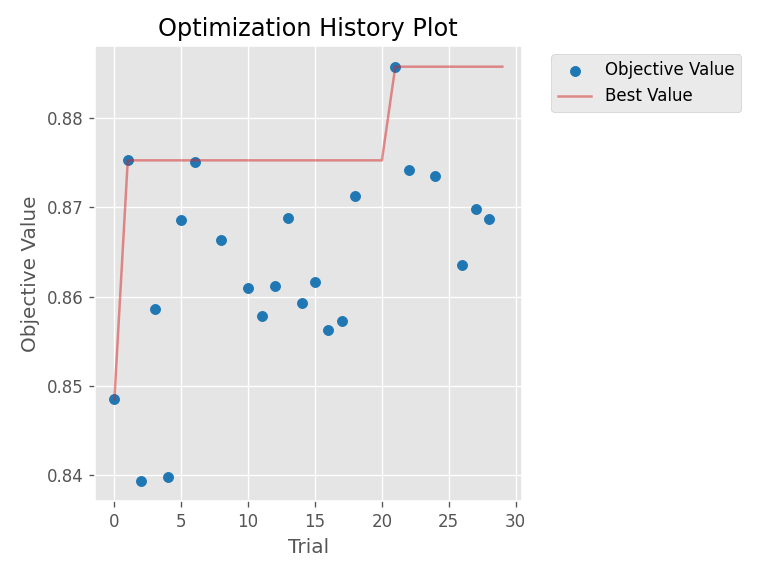

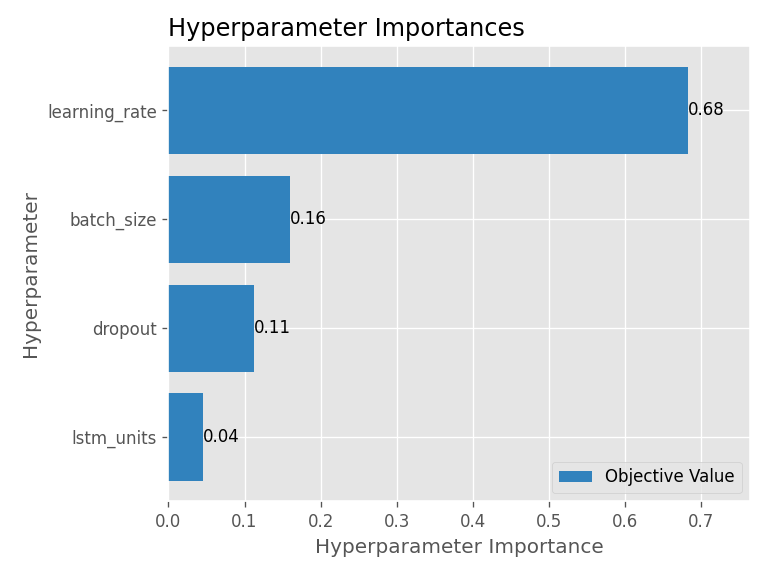

In [4]:
from IPython.display import Image

display(Image(filename=str(REPO_ROOT / "artifacts" / "figures" / "optuna_history.png")))
display(Image(filename=str(REPO_ROOT / "artifacts" / "figures" / "optuna_importances.png")))


## Why the baseline ships anyway (ADR-004)

The winning trial's own held-out `val_auc` (0.8857) beat every other trial, so the search is
working. But retraining that configuration on train+val for its `best_epoch` and scoring once on
the combined test split did **not** beat the Sprint 1 baseline:

In [5]:
eval_test = json.loads(Path("artifacts/reports/eval_test.json").read_text())
eval_tuned = json.loads(Path("artifacts/reports/eval_test_tuned.json").read_text())
model_best = yaml.safe_load(Path("configs/model.best.yaml").read_text())

comparison = pd.DataFrame([
    {"model": "baseline (lstm_head_baseline)", "roc_auc": eval_test["roc_auc"]["value"],
     "accuracy": eval_test["accuracy"]["value"], "f1": eval_test["f1"]["value"]},
    {"model": "tuned (lstm_head_tuned)", "roc_auc": eval_tuned["roc_auc"]["value"],
     "accuracy": eval_tuned["accuracy"]["value"], "f1": eval_tuned["f1"]["value"]},
])
lh = model_best["lstm_head"]
print(f"winning trial params (configs/model.best.yaml): units={lh['units']}, "
      f"dropout={lh['dropout']:.4f}, lr={lh['learning_rate']:.5f}, "
      f"best_epoch={model_best['tuned_best_epoch']}")
comparison


winning trial params (configs/model.best.yaml): units=128, dropout=0.4921, lr=0.00486, best_epoch=7


,model,roc_auc,accuracy,f1
0,baseline (lstm_head_baseline),0.944990,0.876923,0.893048
1,tuned (lstm_head_tuned),0.941829,0.870769,0.888298


Tuning did not beat the baseline on test (0.9418 vs. 0.9450 ROC-AUC); per `docs/SPRINT_PLAN.md`'s
"no cherry-picking" rule, the baseline ships and both numbers are reported as-is. ADR-004's
leading hypothesis: the retrain step reuses the winning trial's tuning-time `best_epoch` as a
fixed epoch count for the larger train+val fit, rather than re-tuning it, so the final fit may be
mildly undertrained relative to its own optimum.

## AIRTLab fine-tune: 5-fold grouped cross-validation

AIRTLab has only 175 recorded events (350 clips, two camera views each), too few for a single train/val/test fit to give a stable number. `GroupKFold` over `group_id` keeps both camera views of one event in the same fold. Each fold fine-tunes fresh from the Sprint 1 baseline's weights at a low learning rate (1e-4), never continuing a previous fold's fit. Real per-fold results from the committed `eval_finetuned.json`:

In [6]:
finetuned = json.loads(Path("artifacts/reports/eval_finetuned.json").read_text())
fold_cols = ["fold", "n_train", "n_test", "accuracy", "f1", "roc_auc"]
fold_df = pd.DataFrame(finetuned["fold_reports"])[fold_cols]
display(fold_df)

summary = finetuned["cv_summary"]
print("mean +/- std across folds:")
for metric, stats in summary.items():
    print(f"  {metric:10s} {stats['mean']:.4f} +/- {stats['std']:.4f}")


,fold,n_train,n_test,accuracy,f1,roc_auc
0,0,280,70,0.885714,0.914894,0.863225
1,1,280,70,0.800000,0.851064,0.864583
2,2,280,70,0.828571,0.880000,0.869755
3,3,280,70,0.914286,0.934783,0.973732
4,4,280,70,0.814286,0.850575,0.916667


mean +/- std across folds:
  accuracy   0.8486 +/- 0.0439
  f1         0.8863 +/- 0.0338
  roc_auc    0.8976 +/- 0.0429


## Catastrophic forgetting check

RWF-2000 val ROC-AUC, baseline checkpoint vs. the checkpoint fine-tuned on the full AIRTLab pool:

In [7]:
forgetting = finetuned["forgetting_check"]
print(f"before (baseline):           {forgetting['roc_auc_before']:.4f}")
print(f"after (AIRTLab fine-tuned):  {forgetting['roc_auc_after']:.4f}")
print(f"drop:                        {forgetting['roc_auc_drop']:+.4f}")


before (baseline):           0.7150
after (AIRTLab fine-tuned):  0.6568
drop:                        +0.0582


ADR-005 ships the AIRTLab-fine-tuned checkpoint (`finetuned_airtlab_lstm_head.keras`) despite this
drop: AIRTLab AUC rises from 0.53 (zero-shot, notebook 04) to 0.90 (CV mean), and AIRTLab is the
one dataset in this pipeline that matches the stated women's-safety use case, while RWF-2000 stays
well above chance (0.657) after the drop. This checkpoint, not the Sprint 1/2 baseline, is what
Sprint 5's ONNX export and Flask app serve (notebook 06).

## Limitations

- **AIRTLab is acted, staged footage**, not organic violence; its CV numbers reflect
  generalisation across camera angle and individual within that staged-violence task, not to
  unscripted real-world footage.
- **The forgetting check uses one fine-tuned checkpoint (full-pool), not a per-fold average**;
  it is a single before/after comparison, not a cross-validated one.
- The HPO search tuned the head's hyperparameters only; there is no backbone to unfreeze in this
  architecture (ADR-003), so backbone freeze depth was never a search dimension.
